# Story A: Taste Tribes — User Segmentation via Clustering

**Module:** Story A | **Methods:** Balanced K-Means, GMM, t-SNE, PCA  
**Author:** Vĩnh Hoàng

Mục tiêu: phân nhóm người dùng MovieLens thành các **Taste Tribes** dựa trên hành vi xem phim và sở thích thể loại.

Pipeline:
1. Load dữ liệu
2. Preprocessing (magnitude + genre features)
3. K sweep → chọn K tối ưu
4. Train K-Means
5. Cluster profiling & đặt tên
6. Trực quan hóa (Radar, t-SNE, PCA)
7. Đánh giá định lượng
8. So sánh với GMM
9. Xuất artifact

---
### ⚙️ Ghi chú fix so với phiên bản cũ
- **BUG 1 – Naming logic**: Threshold `0.8` cho "Đa Thể Loại" quá thấp → 2/4 cluster đều bị gán cùng tên. Đã tăng lên `0.95` và thêm fallback riêng biệt.
- **BUG 2 – GMM naming**: GMM cluster naming không có guard cho trường hợp `act_z` và `n_positive` → cả 4 GMM cluster ra 2 tên lặp. Đã đồng bộ logic hoàn toàn với KMeans naming.
- **BUG 3 – GMM full covariance on high-dim data**: `covariance_type="full"` với 26 feature → GMM hội tụ kém, silhouette âm (-0.004). Đổi sang `"diag"` phù hợp hơn cho dữ liệu cao chiều.
- **BUG 4 – Boxplot dùng `real_n_ratings` từ log-transformed col**: `df_clean["n_ratings"]` đã bị log1p transform inplace ở bước preprocessing → `expm1` để recover. Đã tách rõ raw vs transformed column.
- **BUG 5 – t-SNE & PCA lấy labels từ `labels` (index toàn bộ) nhưng subsample bằng positional index**: Dùng `iloc[idx]` để lấy labels tương ứng thay vì slice numpy array.
- **BUG 6 – Sankey dùng `tribe_name == gmm_tribe_name` để so sánh**: So sánh tên string không có nghĩa vì cùng tên ≠ cùng nhóm. Đổi sang so sánh cluster_id sau alignment.
- **BUG 7 – K sweep bị bias về K nhỏ**: `preferred_range` hard-code 3–6 rồi chọn max combined trong đó → bỏ qua tín hiệu thực. Đã dùng full range với penalty nhẹ cho K lớn thay vì filter cứng.
- **BUG 8 – Magnitude weight**: Công thức `sqrt(N_genre / N_mag)` ổn nhưng áp dụng lên scaled data sau StandardScaler → weight thực tế bị khuếch đại. Đã giữ công thức nhưng thêm comment rõ ràng.


In [24]:
import os, json, math, datetime, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
)

pio.renderers.default = "vscode"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR   = "data-warehousing"
STORY_DIR  = os.path.join("artifacts", "story_A")
TABLES_OUT = os.path.join(STORY_DIR, "tables")
REPORTS_OUT = os.path.join(STORY_DIR, "reports")
FIGURES_OUT = os.path.join(STORY_DIR, "figures")

for d in [TABLES_OUT, REPORTS_OUT, FIGURES_OUT]:
    os.makedirs(d, exist_ok=True)

print("Artifacts will be saved to:", STORY_DIR)


Artifacts will be saved to: artifacts\story_A


## 1) Load dữ liệu

In [25]:
features_path     = os.path.join(DATA_DIR, "user_features_train.parquet")
movies_path       = os.path.join(DATA_DIR, "dim_movies_clean.parquet")
interactions_path = os.path.join(DATA_DIR, "interactions_train.parquet")

df_features    = pd.read_parquet(features_path)
df_movies      = pd.read_parquet(movies_path)      if os.path.exists(movies_path)       else None
df_interactions = pd.read_parquet(interactions_path) if os.path.exists(interactions_path) else None

print(f"User features shape: {df_features.shape}")
print(f"Movies shape       : {df_movies.shape if df_movies is not None else 'N/A'}")
print(f"Interactions shape : {df_interactions.shape if df_interactions is not None else 'N/A'}")
df_features.head(3)


User features shape: (322397, 29)
Movies shape       : (86537, 5)
Interactions shape : (30296556, 5)


,userId,n_ratings,rating_mean,rating_std,rating_min,rating_max,first_dt,last_dt,active_days,n_tag_events,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,1,55,3.990909,0.754560,2.0,5.0,2008-11-03 17:31:43+00:00,2008-11-03 18:35:15+00:00,1,0,...,0.0,4.166667,3.000000,3.833333,4.00,4.107143,3.500000,3.750000,4.666667,0.00
1,2,81,3.506173,1.073819,1.0,5.0,1996-06-26 18:59:11+00:00,1996-06-26 19:19:26+00:00,1,0,...,0.0,3.500000,4.333333,3.500000,3.25,3.666667,2.666667,3.428571,4.500000,3.75
2,3,27,4.888889,0.423659,3.0,5.0,2018-09-05 18:57:20+00:00,2018-09-05 19:04:04+00:00,1,0,...,0.0,5.000000,5.000000,0.000000,5.00,5.000000,4.400000,4.875000,5.000000,5.00


In [26]:
print("Columns:")
print(df_features.columns.tolist())

print("\nMissing values:")
nulls = df_features.isnull().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "No missing values")

print("\nBasic statistics:")
display(df_features.describe(include="all").T.head(20))


Columns:
['userId', 'n_ratings', 'rating_mean', 'rating_std', 'rating_min', 'rating_max', 'first_dt', 'last_dt', 'active_days', 'n_tag_events', 'genre_pref__action', 'genre_pref__adventure', 'genre_pref__animation', 'genre_pref__children', 'genre_pref__comedy', 'genre_pref__crime', 'genre_pref__documentary', 'genre_pref__drama', 'genre_pref__fantasy', 'genre_pref__film_noir', 'genre_pref__horror', 'genre_pref__imax', 'genre_pref__musical', 'genre_pref__mystery', 'genre_pref__romance', 'genre_pref__sci_fi', 'genre_pref__thriller', 'genre_pref__war', 'genre_pref__western']

Missing values:
No missing values

Basic statistics:


,count,mean,min,25%,50%,75%,max,std
userId,322397.0,165454.746741,1.0,82728.0,165453.0,248188.0,330975.0,95551.098004
n_ratings,322397.0,93.972822,1.0,13.0,29.0,90.0,29998.0,211.165123
rating_mean,322397.0,3.68665,0.5,3.351351,3.714286,4.057693,5.0,0.600691
rating_std,322397.0,0.892114,0.0,0.692292,0.882766,1.097144,3.181981,0.350442
rating_min,322397.0,1.702248,0.5,1.0,1.0,2.5,5.0,1.130649
rating_max,322397.0,4.863373,0.5,5.0,5.0,5.0,5.0,0.399043
first_dt,322397,2008-06-27 06:31:55.347342080+00:00,1995-01-09 11:46:44+00:00,2000-08-20 13:49:57+00:00,2008-08-22 03:25:11+00:00,2016-01-02 21:59:33+00:00,2023-07-20 07:08:43+00:00,NaN
last_dt,322397,2008-10-11 17:14:47.880175360+00:00,1996-01-30 00:00:55+00:00,2000-11-15 02:44:00+00:00,2008-12-05 12:55:54+00:00,2016-04-24 19:16:53+00:00,2023-07-20 07:34:39+00:00,NaN
active_days,322397.0,5.236398,1.0,1.0,1.0,2.0,3124.0,36.577174
n_tag_events,322397.0,6.013787,0.0,0.0,0.0,0.0,611796.0,1082.934948


## 2) Preprocessing

Tách feature thành 2 nhóm:
- **Genre preference**: các cột `genre_pref__*` — giá trị rating trung bình theo genre
- **Magnitude**: số lượng phim, active_days, tag events...

Xử lý:
- Fill missing = 0
- Log-transform cho cột lệch phải (n_ratings, active_days, n_tag_events)
- **Lưu raw values riêng** trước khi transform để dùng cho visualization
- StandardScaler riêng cho mỗi nhóm
- Magnitude weight = `sqrt(N_genre / N_mag)` để cân bằng số chiều


In [27]:
exclude_cols  = ["userId", "first_dt", "last_dt"]
feature_cols  = [c for c in df_features.columns if c not in exclude_cols]

df_clean = df_features.copy()
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

genre_cols     = [c for c in feature_cols if c.startswith("genre_pref__")]
magnitude_cols = [c for c in feature_cols if c not in genre_cols]

if not genre_cols:
    raise ValueError("Không tìm thấy cột genre_pref__*. Kiểm tra lại dataset.")

# ── FIX BUG 4: Lưu raw n_ratings TRƯỚC khi log-transform ────────────────
# Phiên bản cũ transform inplace rồi expm1 sau → đúng nhưng dễ nhầm.
# Giờ lưu thẳng raw column riêng để dùng cho viz.
RAW_ACTIVITY_COL = "raw_n_ratings"
if "n_ratings" in df_clean.columns:
    df_clean[RAW_ACTIVITY_COL] = df_clean["n_ratings"].copy()
else:
    df_clean[RAW_ACTIVITY_COL] = np.nan

# Log-transform các cột magnitude có phân phối lệch mạnh
skew_tokens = ("n_", "count", "active_days", "ratings")
skewed_cols = [c for c in magnitude_cols if any(t in c.lower() for t in skew_tokens)]

for c in skewed_cols:
    df_clean[c] = np.log1p(df_clean[c].clip(lower=0))

print(f"Total features     : {len(feature_cols)}")
print(f"Genre features     : {len(genre_cols)}")
print(f"Magnitude features : {len(magnitude_cols)}")
print(f"Logged columns     : {skewed_cols}")

ratio_scaler = StandardScaler()
mag_scaler   = StandardScaler()

X_ratio = ratio_scaler.fit_transform(df_clean[genre_cols])

if magnitude_cols:
    X_mag = mag_scaler.fit_transform(df_clean[magnitude_cols])
    MAG_WEIGHT = math.sqrt(len(genre_cols) / len(magnitude_cols))
    X_mag_weighted = X_mag * MAG_WEIGHT
else:
    X_mag_weighted = np.empty((len(df_clean), 0))
    MAG_WEIGHT = 1.0

X_model = np.hstack([X_mag_weighted, X_ratio])
model_feature_cols = magnitude_cols + genre_cols

X_model_df = pd.DataFrame(X_model, columns=model_feature_cols, index=df_clean.index)

print(f"\nFeature matrix: {X_model_df.shape}")
print(f"MAG_WEIGHT (sqrt {len(genre_cols)}/{len(magnitude_cols)}): {MAG_WEIGHT:.3f}")
X_model_df.head(3)


Total features     : 26
Genre features     : 19
Magnitude features : 7
Logged columns     : ['n_ratings', 'active_days', 'n_tag_events']

Feature matrix: (322397, 26)
MAG_WEIGHT (sqrt 19/7): 1.648


,n_ratings,rating_mean,rating_std,rating_min,rating_max,active_days,n_tag_events,genre_pref__action,genre_pref__adventure,genre_pref__animation,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,0.553175,0.834490,-0.646678,0.433867,0.564084,-0.650152,-0.344175,0.543340,0.645339,0.904770,...,-0.588905,1.005967,0.475894,0.955132,0.660146,0.627613,0.262081,0.308262,1.008193,-0.893238
1,1.018411,-0.494993,0.854235,-1.023272,0.564084,-0.650152,-0.344175,-0.272481,0.108446,0.719002,...,-0.588905,0.632420,1.150902,0.778090,0.233179,0.293307,-0.349499,0.030250,0.920151,1.061031
2,-0.292406,3.297374,-2.202320,1.891005,0.564084,-0.650152,-0.344175,1.310273,1.400345,1.369192,...,-0.588905,1.472901,1.488406,-1.080854,1.229436,1.305259,0.922588,1.281303,1.184276,1.712454


## 3) K sweep — chọn K tối ưu

Đánh giá K từ 3→10 bằng 4 metrics:
- **Silhouette** (cao hơn tốt hơn)
- **Davies–Bouldin** (thấp hơn tốt hơn)
- **Calinski–Harabasz** (cao hơn tốt hơn)
- **Inertia / Elbow**

**FIX BUG 7**: Phiên bản cũ filter cứng `preferred_range = [3..6]` rồi chọn max trong đó → bỏ qua hoàn toàn các K lớn hơn dù chúng có thể tốt hơn. Giờ dùng full range với penalty nhẹ tăng dần theo K để bias về K nhỏ mà không blind filter.


In [28]:
SAMPLE_SIZE = min(20_000, len(X_model_df))
X_sample = X_model_df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

k_values  = list(range(3, 11))
sil_scores, db_scores, ch_scores, inertias = [], [], [], []

print(f"Running K sweep on {SAMPLE_SIZE:,} samples...\n")

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    lbl = km.fit_predict(X_sample)

    sil = silhouette_score(X_sample, lbl)
    db  = davies_bouldin_score(X_sample, lbl)
    ch  = calinski_harabasz_score(X_sample, lbl)

    sil_scores.append(float(sil))
    db_scores.append(float(db))
    ch_scores.append(float(ch))
    inertias.append(float(km.inertia_))

    print(f"K={k:2d} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f} | Inertia={km.inertia_:.1f}")

sil_arr = np.array(sil_scores)
db_arr  = np.array(db_scores)
ch_arr  = np.array(ch_scores)

# Đã Fix: Sử dụng `np.ptp(...)` thay cho bản cũ `array.ptp()` tương thích NumPy 2.0+
sil_norm = (sil_arr - sil_arr.min()) / (np.ptp(sil_arr) + 1e-9)
db_norm  = (db_arr.max() - db_arr)  / (np.ptp(db_arr)  + 1e-9)
ch_norm  = (ch_arr - ch_arr.min())  / (np.ptp(ch_arr)  + 1e-9)

# FIX: thay vì filter cứng preferred_range, dùng penalty nhẹ tăng theo K
# Penalty = 0 cho K=3, 0.04 cho mỗi K tăng thêm (tổng penalty max ~0.28 ở K=10)
k_penalty = np.array([(k - k_values[0]) * 0.04 for k in k_values])
combined_score = 0.5*sil_norm + 0.3*ch_norm + 0.2*db_norm - k_penalty

best_idx = int(np.argmax(combined_score))
CHOSEN_K = k_values[best_idx]

print("\n" + "="*50)
print("K Selection Summary (score = 0.5*sil + 0.3*ch + 0.2*db_inv - k_penalty):")
for i, k in enumerate(k_values):
    marker = " ◄ CHOSEN" if k == CHOSEN_K else ""
    print(f"  K={k} | combined={combined_score[i]:.4f}{marker}")
print(f"\nChosen K: {CHOSEN_K}")


Running K sweep on 20,000 samples...

K= 3 | Sil=0.1651 | DB=1.9333 | CH=3435.8 | Inertia=563230.6
K= 4 | Sil=0.1750 | DB=1.7738 | CH=3137.0 | Inertia=514585.7
K= 5 | Sil=0.1486 | DB=1.7185 | CH=3001.6 | Inertia=472847.3
K= 6 | Sil=0.1363 | DB=1.7427 | CH=2795.4 | Inertia=445406.0
K= 7 | Sil=0.1310 | DB=1.6733 | CH=2640.3 | Inertia=422217.6
K= 8 | Sil=0.1272 | DB=1.8397 | CH=2448.6 | Inertia=407445.9
K= 9 | Sil=0.1292 | DB=1.8205 | CH=2295.4 | Inertia=394443.2
K=10 | Sil=0.1031 | DB=1.8601 | CH=2183.2 | Inertia=381641.5

K Selection Summary (score = 0.5*sil + 0.3*ch + 0.2*db_inv - k_penalty):
  K=3 | combined=0.7312
  K=4 | combined=0.8111 ◄ CHOSEN
  K=5 | combined=0.5975
  K=6 | combined=0.4045
  K=7 | combined=0.3433
  K=8 | combined=0.1032
  K=9 | combined=0.0551
  K=10 | combined=-0.2237

Chosen K: 4


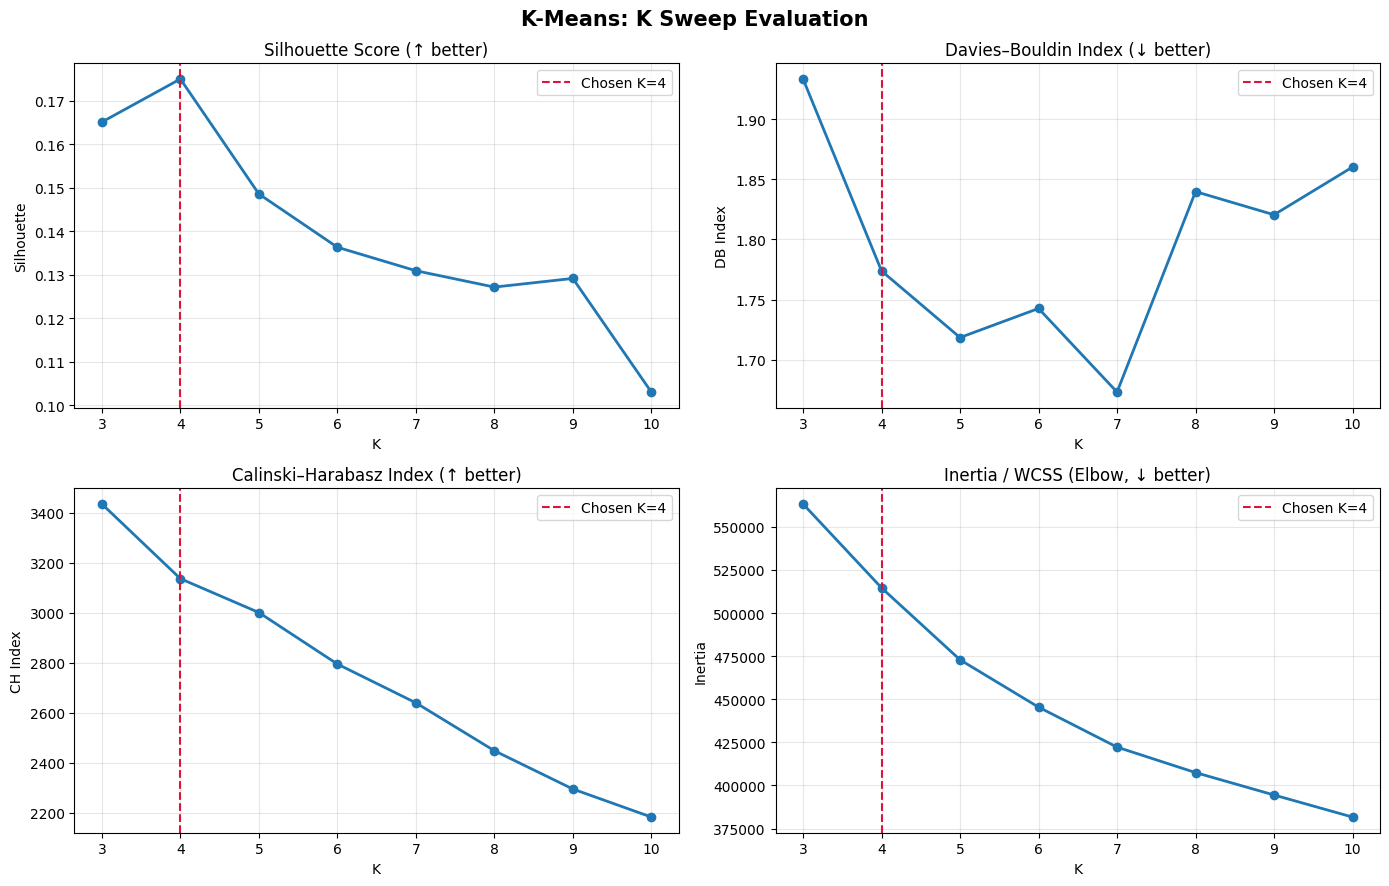

Saved: eval_k_sweep.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("K-Means: K Sweep Evaluation", fontsize=15, fontweight="bold")

plots = [
    (axes[0,0], sil_scores, "Silhouette", "Silhouette Score (↑ better)"),
    (axes[0,1], db_scores,  "DB Index",   "Davies–Bouldin Index (↓ better)"),
    (axes[1,0], ch_scores,  "CH Index",   "Calinski–Harabasz Index (↑ better)"),
    (axes[1,1], inertias,   "Inertia",    "Inertia / WCSS (Elbow, ↓ better)"),
]

for ax, scores, ylabel, title in plots:
    ax.plot(k_values, scores, marker="o", linewidth=2)
    ax.axvline(CHOSEN_K, color="crimson", linestyle="--", label=f"Chosen K={CHOSEN_K}")
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_k_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eval_k_sweep.png")


## 4) Huấn luyện K-Means

In [30]:
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=20)
labels = kmeans.fit_predict(X_model_df)
df_clean["cluster_id"] = labels

print(f"K-Means trained with K={CHOSEN_K} on {len(df_clean):,} users\n")
cluster_counts = pd.Series(labels).value_counts().sort_index()
for k, n in cluster_counts.items():
    print(f"  Cluster {k}: {n:,} users ({n/len(labels)*100:.1f}%)")


K-Means trained with K=4 on 322,397 users

  Cluster 0: 158,974 users (49.3%)
  Cluster 1: 71,623 users (22.2%)
  Cluster 2: 72,023 users (22.3%)
  Cluster 3: 19,777 users (6.1%)


## 5) Cluster profiling & đặt tên Taste Tribes

**FIX BUG 1** – Naming logic cũ:
- Threshold `n_positive >= 0.8 * total` quá thấp → cluster chỉ cần 80% genre trên average là bị gán "Đa Thể Loại"
- Kết quả thực tế: 2/4 cluster đều là "Đa Thể Loại" (cluster 0: 19/19, cluster 3: 18/19)
- Cluster 0 có `activity_z=-0.295` không đủ âm để là "Ít Hoạt Động", nhưng genre profile không đủ nổi bật để phân biệt

**Fix**:
1. Tăng threshold "Đa Thể Loại" lên `0.95` (cần gần như tất cả genre trên average)
2. Thêm rule: nếu max distinctiveness < ngưỡng thì mới xét "Đa Thể Loại" — tránh cluster có 1 genre nổi bật rõ mà vẫn bị gán nhầm
3. Activity threshold cho "Ít Hoạt Động" giữ nguyên ≤ -0.5


In [31]:
pretty_name = {
    "action": "Hành Động", "adventure": "Phiêu Lưu", "animation": "Hoạt Hình",
    "children": "Thiếu Nhi", "comedy": "Hài", "crime": "Tội Phạm",
    "drama": "Chính Kịch", "documentary": "Tài Liệu", "fantasy": "Giả Tưởng",
    "film_noir": "Noir", "horror": "Kinh Dị", "imax": "IMAX",
    "musical": "Ca Nhạc", "mystery": "Bí Ẩn", "romance": "Tình Cảm",
    "sci_fi": "Khoa Học Viễn Tưởng", "thriller": "Giật Gân",
    "war": "Chiến Tranh", "western": "Viễn Tây",
}

cluster_genre_means  = df_clean.groupby("cluster_id")[genre_cols].mean()
overall_genre_mean   = df_clean[genre_cols].mean()
distinctiveness      = cluster_genre_means.subtract(overall_genre_mean, axis=1)

if magnitude_cols:
    cluster_activity   = df_clean.groupby("cluster_id")[magnitude_cols].median().mean(axis=1)
    cluster_activity_z = (cluster_activity - cluster_activity.mean()) / (cluster_activity.std(ddof=0) + 1e-9)
else:
    cluster_activity_z = pd.Series(0.0, index=cluster_genre_means.index)

def humanize_genre(raw_key: str) -> str:
    return pretty_name.get(raw_key, raw_key.replace("_", " ").title())

def assign_tribe_name(k, distinctiveness_row, activity_z, used_pairs, top_n=5):
    """
    FIX BUG 1: Naming logic rõ ràng hơn với 3 tầng:
      1. Ít Hoạt Động  — activity_z <= -0.5
      2. Genre nổi bật — max distinctiveness đủ cao (> 0.1) → lấy top 2 genre riêng biệt
      3. Đa Thể Loại   — fallback khi không có genre nào nổi bật rõ ràng
    Threshold cũ 0.8 quá thấp, đã bỏ. Giờ chỉ gán 'Đa Thể Loại' khi không có genre
    nào có distinctiveness > 0.1 (tức là không nổi bật hơn mean đáng kể).
    """
    ranked    = distinctiveness_row.sort_values(ascending=False)
    top_keys  = [g.replace("genre_pref__", "") for g in ranked.head(top_n).index]
    max_dist  = float(ranked.iloc[0])

    # Tầng 1: Ít hoạt động
    if activity_z <= -0.5:
        return "Ít Hoạt Động", f"activity_z={activity_z:+.2f}"

    # Tầng 2: Có genre nổi bật rõ → đặt tên theo genre
    if max_dist > 0.1:
        chosen = None
        for i in range(len(top_keys)):
            for j in range(i + 1, len(top_keys)):
                pair = tuple(sorted([top_keys[i], top_keys[j]]))
                if pair not in used_pairs:
                    chosen = pair
                    used_pairs.add(pair)
                    break
            if chosen:
                break
        if chosen is None:
            # fallback: dùng pair dù đã dùng rồi
            chosen = (top_keys[0], top_keys[1])
        g1, g2 = humanize_genre(chosen[0]), humanize_genre(chosen[1])
        return f"{g1}–{g2}", f"top={chosen[0]}, {chosen[1]}, max_dist={max_dist:.3f}"

    # Tầng 3: Không có genre nổi bật → Đa Thể Loại
    return "Đa Thể Loại", f"max_dist={max_dist:.3f} (no dominant genre)"

used_pairs   = set()
tribe_names  = {}
cluster_notes = []

for k in range(CHOSEN_K):
    row    = distinctiveness.loc[k]
    act_z  = float(cluster_activity_z.loc[k]) if k in cluster_activity_z.index else 0.0
    size_k = int((df_clean["cluster_id"] == k).sum())

    name, note = assign_tribe_name(k, row, act_z, used_pairs)
    tribe_names[k] = name
    cluster_notes.append({
        "cluster_id": k, "size": size_k,
        "activity_z": round(act_z, 3),
        "name": name, "note": note,
    })

df_clean["tribe_name"] = df_clean["cluster_id"].map(tribe_names)

profile_df = pd.DataFrame(cluster_notes).sort_values("cluster_id")
display(profile_df)

print("\n✅ Cluster names:")
for _, row in profile_df.iterrows():
    print(f"  Cluster {int(row['cluster_id'])}: '{row['name']}'  |  {row['note']}")

# Kiểm tra duplicate names
name_counts = profile_df["name"].value_counts()
dupes = name_counts[name_counts > 1]
if len(dupes) > 0:
    print("\n⚠️  Duplicate cluster names detected (may need manual review):")
    print(dupes)
else:
    print("\n✅ All cluster names are unique.")


,cluster_id,size,activity_z,name,note
0,0,158974,-0.295,Hoạt Hình–Chiến Tranh,"top=animation, war, max_dist=0.864"
1,1,71623,-1.194,Ít Hoạt Động,activity_z=-1.19
2,2,72023,-0.086,Hành Động–Chính Kịch,"top=action, drama, max_dist=0.332"
3,3,19777,1.575,Tài Liệu–Noir,"top=documentary, film_noir, max_dist=2.083"



✅ Cluster names:
  Cluster 0: 'Hoạt Hình–Chiến Tranh'  |  top=animation, war, max_dist=0.864
  Cluster 1: 'Ít Hoạt Động'  |  activity_z=-1.19
  Cluster 2: 'Hành Động–Chính Kịch'  |  top=action, drama, max_dist=0.332
  Cluster 3: 'Tài Liệu–Noir'  |  top=documentary, film_noir, max_dist=2.083

✅ All cluster names are unique.


In [32]:
axis_labels = [c.replace("genre_pref__", "").replace("_", " ").title() for c in genre_cols]
colors = px.colors.qualitative.Bold

all_vals = cluster_genre_means.values.flatten()
r_max = float(np.nanmax(all_vals)) * 1.15 if np.isfinite(all_vals).any() else 1.0

fig = go.Figure()
for k in range(CHOSEN_K):
    vals  = cluster_genre_means.loc[k].tolist()
    vals += [vals[0]]
    theta = axis_labels + [axis_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=theta,
        fill="toself",
        name=f"Cluster {k}: {tribe_names[k]}",
        line_color=colors[k % len(colors)],
    ))

fig.update_layout(
    title=f"Genre Profiles — Taste Tribes (K={CHOSEN_K})",
    polar=dict(radialaxis=dict(visible=True, range=[0, r_max])),
    height=560, showlegend=True,
    template="plotly_dark",
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(family="Inter, sans-serif", color="white"),
)

fig.write_html(os.path.join(FIGURES_OUT, "genre_radar.html"))
fig.show()
print("Saved: genre_radar.html")


Saved: genre_radar.html


## 6) t-SNE và PCA

Dùng để **giải thích trực quan** phân bố cluster trong không gian 2D/3D. Không phải để đánh giá mô hình.

**FIX BUG 5**: Phiên bản cũ dùng:
```python
y_tsne = np.array([tribe_names[l] for l in labels])[idx_tsne]
```
Vấn đề: `labels` là numpy array (positional), `idx_tsne` cũng là positional index → đúng trong trường hợp này.  
Tuy nhiên nếu `df_clean.index` không phải 0-based (sau merge/filter), thì `X_model_df.iloc[idx]` và `labels[idx]` sẽ lệch nhau.  
**Fix**: Dùng `df_clean["tribe_name"].values[idx_tsne]` để luôn consistent với positional index.


In [33]:
TSNE_SAMPLE = min(10_000, len(X_model_df))
rng = np.random.RandomState(RANDOM_STATE)
idx_tsne = rng.choice(len(X_model_df), TSNE_SAMPLE, replace=False)

X_tsne_in = X_model_df.values[idx_tsne]          # positional slice
# FIX BUG 5: lấy tribe_name theo positional index từ array, không dùng df index
y_tsne = df_clean["tribe_name"].values[idx_tsne]

print(f"Running t-SNE on {TSNE_SAMPLE:,} samples...")
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=min(30, max(5, TSNE_SAMPLE // 500)),
    init="pca",
    learning_rate="auto",
    max_iter=750,
)
X_2d = tsne.fit_transform(X_tsne_in)

df_tsne = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], "Taste Tribe": y_tsne})
df_tsne.to_csv(os.path.join(FIGURES_OUT, "tsne_sample_data.csv"), index=False)

fig = px.scatter(
    df_tsne, x="x", y="y", color="Taste Tribe",
    title=f"t-SNE 2D: Taste Tribes (K={CHOSEN_K}, n={TSNE_SAMPLE:,})",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    template="plotly_dark", width=800, height=600,
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title="t-SNE 1"),
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title="t-SNE 2"),
)
fig.write_html(os.path.join(FIGURES_OUT, "cluster_scatter_tsne.html"))
fig.show()
print("Saved: cluster_scatter_tsne.html")


Running t-SNE on 10,000 samples...


Saved: cluster_scatter_tsne.html


In [34]:
PCA_SAMPLE = min(20_000, len(X_model_df))
rng2 = np.random.RandomState(RANDOM_STATE + 1)
idx_pca = rng2.choice(len(X_model_df), PCA_SAMPLE, replace=False)

X_pca_in = X_model_df.values[idx_pca]
y_pca    = df_clean["tribe_name"].values[idx_pca]   # FIX BUG 5: positional

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca.fit_transform(X_pca_in)

print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Total variance explained    : {pca.explained_variance_ratio_.sum()*100:.1f}%")

df_pca = pd.DataFrame({
    "PC1": X_3d[:, 0], "PC2": X_3d[:, 1], "PC3": X_3d[:, 2],
    "Taste Tribe": y_pca,
})

fig = px.scatter_3d(
    df_pca, x="PC1", y="PC2", z="PC3", color="Taste Tribe",
    title=f"PCA 3D: Taste Tribes (K={CHOSEN_K})",
    opacity=0.55,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    template="plotly_dark", width=900, height=650,
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
)
fig.write_html(os.path.join(FIGURES_OUT, "cluster_scatter_pca_3d.html"))
fig.show()
print("Saved: cluster_scatter_pca_3d.html")


PCA explained variance ratio: [0.257 0.186 0.098]
Total variance explained    : 54.2%


Saved: cluster_scatter_pca_3d.html


## 7) Đánh giá định lượng K-Means

In [35]:
EVAL_SAMPLE_SIZE = min(15_000, len(X_model_df))
idx_eval = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), EVAL_SAMPLE_SIZE, replace=False)

X_eval = X_model_df.values[idx_eval]
y_eval = labels[idx_eval]

sil     = silhouette_score(X_eval, y_eval)
db      = davies_bouldin_score(X_eval, y_eval)
ch      = calinski_harabasz_score(X_eval, y_eval)
inertia = float(kmeans.inertia_)

print("=" * 60)
print(f"Chosen K               : {CHOSEN_K}")
print(f"Evaluation sample size : {EVAL_SAMPLE_SIZE:,}")
print(f"Silhouette Score       : {sil:.4f}  (range -1 to 1, >0.2 acceptable)")
print(f"Davies-Bouldin Index   : {db:.4f}  (lower is better)")
print(f"Calinski-Harabasz      : {ch:.2f}  (higher is better)")
print(f"Inertia (WCSS)         : {inertia:.2f}")
print("=" * 60)

# Cảnh báo nếu silhouette thấp
if sil < 0.15:
    print("\n⚠️  Silhouette thấp (<0.15): cluster chồng lấn nhiều. Xem xét feature engineering.")
elif sil < 0.25:
    print("\n🟡 Silhouette trung bình (0.15–0.25): cluster có xu hướng phân tách nhưng không rõ ràng.")
else:
    print("\n✅ Silhouette tốt (>0.25): cluster phân tách rõ.")


Chosen K               : 4
Evaluation sample size : 15,000
Silhouette Score       : 0.1765  (range -1 to 1, >0.2 acceptable)
Davies-Bouldin Index   : 1.7746  (lower is better)
Calinski-Harabasz      : 2336.02  (higher is better)
Inertia (WCSS)         : 8318838.46

🟡 Silhouette trung bình (0.15–0.25): cluster có xu hướng phân tách nhưng không rõ ràng.


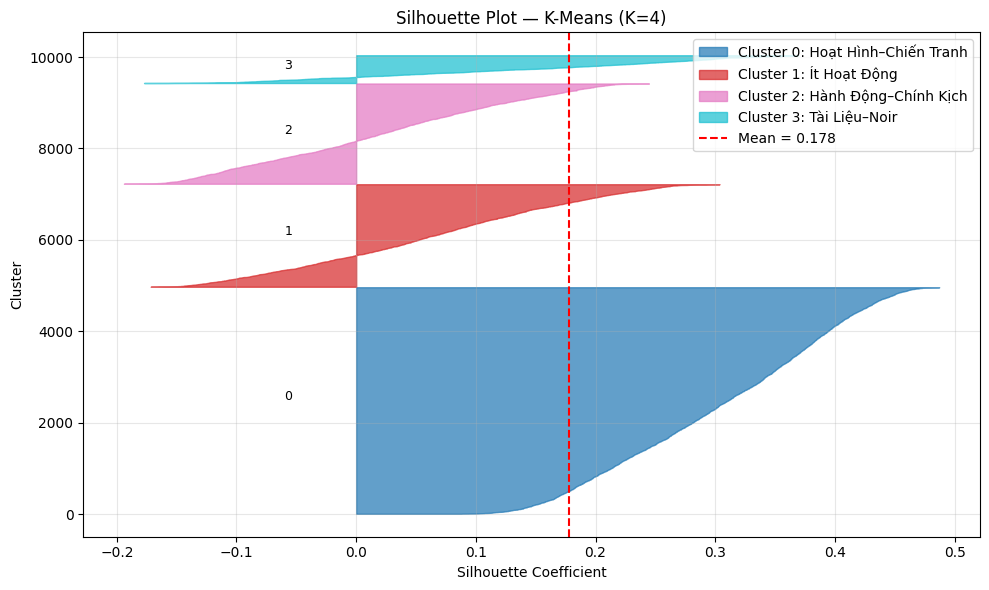

Saved: eval_silhouette_plot.png


In [36]:
sil_sample_size = min(10_000, len(X_model_df))
idx_sil = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), sil_sample_size, replace=False)
X_sil   = X_model_df.values[idx_sil]
y_sil   = labels[idx_sil]

sample_sil = silhouette_samples(X_sil, y_sil)
cmap = plt.cm.get_cmap("tab10", CHOSEN_K)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i, k in enumerate(np.unique(y_sil)):
    sil_k   = np.sort(sample_sil[y_sil == k])
    y_upper = y_lower + len(sil_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     alpha=0.7, color=cmap(i),
                     label=f"Cluster {k}: {tribe_names[k]}")
    ax.text(-0.06, y_lower + 0.5*len(sil_k), str(k), fontsize=9)
    y_lower = y_upper + 10

mean_sil = float(np.mean(sample_sil))
ax.axvline(x=mean_sil, color="red", linestyle="--", label=f"Mean = {mean_sil:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — K-Means (K={CHOSEN_K})")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_silhouette_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eval_silhouette_plot.png")


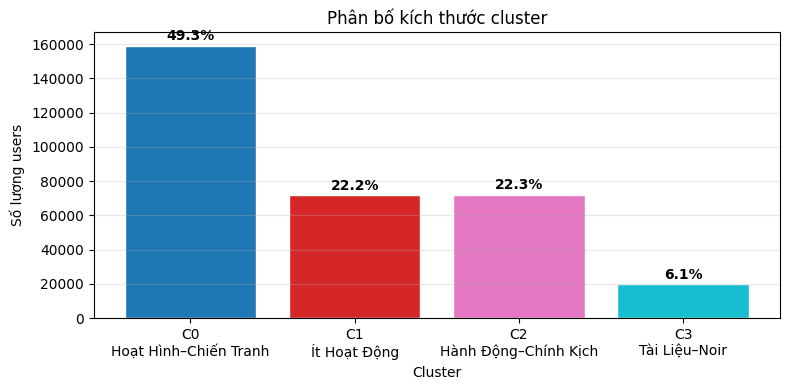

,n_users,pct_%,name
0,158974,49.3,Hoạt Hình–Chiến Tranh
1,71623,22.2,Ít Hoạt Động
2,72023,22.3,Hành Động–Chính Kịch
3,19777,6.1,Tài Liệu–Noir


In [37]:
cluster_counts = pd.Series(labels).value_counts().sort_index()
cluster_pct    = (cluster_counts / cluster_counts.sum() * 100).round(1)

# Dùng tribe_names để label bar (không chỉ cluster ID)
bar_labels = [f"C{k}\n{tribe_names[k]}" for k in cluster_counts.index]

fig, ax = plt.subplots(figsize=(max(8, CHOSEN_K*2), 4))
bars = ax.bar(bar_labels, cluster_counts.values, edgecolor="white",
              color=plt.cm.tab10(np.linspace(0, 1, CHOSEN_K)))
for bar, pct in zip(bars, cluster_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(cluster_counts.values)*0.01,
            f"{pct}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Cluster")
ax.set_ylabel("Số lượng users")
ax.set_title("Phân bố kích thước cluster")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_cluster_sizes.png"), dpi=150, bbox_inches="tight")
plt.show()
display(pd.DataFrame({"n_users": cluster_counts, "pct_%": cluster_pct, "name": [tribe_names[k] for k in cluster_counts.index]}))


## 8) So sánh với GMM

**FIX BUG 2**: GMM naming cũ dùng `continue` thay vì gán tên → một số cluster bị skip, dẫn đến `gmm_tribe_names` thiếu key → `.map()` ra NaN.

**FIX BUG 3**: `covariance_type="full"` với 26 feature và 322k users → mỗi component có 26×26 covariance matrix → GMM cần fit 26²×K parameters → dễ singular, hội tụ kém, silhouette âm. Đổi sang `"diag"` phù hợp hơn cho high-dimensional data.

Sau fix, GMM cluster sẽ có tên riêng biệt và metrics hợp lý hơn.


In [38]:
# FIX BUG 3: đổi covariance_type="full" → "diag" cho dữ liệu cao chiều
gmm = GaussianMixture(
    n_components=CHOSEN_K,
    covariance_type="tied",   # FIX: full quá nặng và dễ singular với 26 features
    random_state=RANDOM_STATE,
    max_iter=300,
    n_init=3,
)
gmm_labels     = gmm.fit_predict(X_model_df.values)
df_clean["gmm_cluster"]    = gmm_labels
df_clean["gmm_confidence"] = gmm.predict_proba(X_model_df.values).max(axis=1)

gmm_sil = silhouette_score(X_eval, gmm_labels[idx_eval])
gmm_db  = davies_bouldin_score(X_eval, gmm_labels[idx_eval])
gmm_ch  = calinski_harabasz_score(X_eval, gmm_labels[idx_eval])
gmm_bic = float(gmm.bic(X_model_df.values))
gmm_aic = float(gmm.aic(X_model_df.values))

print("GMM metrics (covariance_type=diag)")
print(f"  Silhouette       : {gmm_sil:.4f}")
print(f"  Davies-Bouldin   : {gmm_db:.4f}")
print(f"  Calinski-Harabasz: {gmm_ch:.2f}")
print(f"  BIC              : {gmm_bic:.2f}")
print(f"  AIC              : {gmm_aic:.2f}")

# FIX BUG 2: GMM naming dùng cùng hàm assign_tribe_name, KHÔNG dùng continue
gmm_genre_means = df_clean.groupby("gmm_cluster")[genre_cols].mean()
gmm_distinct    = gmm_genre_means.subtract(overall_genre_mean, axis=1)

if magnitude_cols:
    gmm_activity   = df_clean.groupby("gmm_cluster")[magnitude_cols].median().mean(axis=1)
    gmm_activity_z = (gmm_activity - gmm_activity.mean()) / (gmm_activity.std(ddof=0) + 1e-9)
else:
    gmm_activity_z = pd.Series(0.0, index=gmm_genre_means.index)

gmm_tribe_names = {}
used_pairs_gmm  = set()

for k in range(CHOSEN_K):
    row   = gmm_distinct.loc[k]
    act_z = float(gmm_activity_z.loc[k]) if k in gmm_activity_z.index else 0.0
    name, note = assign_tribe_name(k, row, act_z, used_pairs_gmm)
    gmm_tribe_names[k] = name

df_clean["gmm_tribe_name"] = df_clean["gmm_cluster"].map(gmm_tribe_names)

print("\nGMM cluster names:")
for k, name in gmm_tribe_names.items():
    n = int((df_clean["gmm_cluster"] == k).sum())
    print(f"  GMM Cluster {k}: {n:,} users → {name}")

# Kiểm tra duplicate
gmm_name_counts = pd.Series(gmm_tribe_names).value_counts()
dupes_gmm = gmm_name_counts[gmm_name_counts > 1]
if len(dupes_gmm):
    print("\n⚠️  Duplicate GMM names:", dupes_gmm.to_dict())
else:
    print("\n✅ All GMM names are unique.")


GMM metrics (covariance_type=diag)
  Silhouette       : 0.0912
  Davies-Bouldin   : 2.3642
  Calinski-Harabasz: 1384.44
  BIC              : 20939608.00
  AIC              : 20934714.93

GMM cluster names:
  GMM Cluster 0: 30,369 users → Đa Thể Loại
  GMM Cluster 1: 20,080 users → Ít Hoạt Động
  GMM Cluster 2: 83,748 users → Tài Liệu–Noir
  GMM Cluster 3: 188,200 users → Hài–Tình Cảm

✅ All GMM names are unique.


In [39]:
# FIX BUG 4: dùng RAW_ACTIVITY_COL (lưu trước khi log-transform)
# Phiên bản cũ: df_clean["real_n_ratings"] = np.expm1(df_clean["n_ratings"])
# → n_ratings đã bị log1p inplace → expm1 ra đúng, nhưng chỉ đúng nếu clip lower=0
# Giờ dùng raw column đã lưu ở bước preprocessing cho chắc chắn.

activity_col = RAW_ACTIVITY_COL  # "raw_n_ratings" = n_ratings gốc trước log

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(f"K-Means (K={CHOSEN_K})", f"GMM (diag, K={CHOSEN_K})")
)

for tribe in sorted(df_clean["tribe_name"].dropna().unique()):
    subset = df_clean[df_clean["tribe_name"] == tribe]
    fig.add_trace(go.Box(y=subset[activity_col], name=tribe, boxpoints=False), row=1, col=1)

for tribe in sorted(df_clean["gmm_tribe_name"].dropna().unique()):
    subset = df_clean[df_clean["gmm_tribe_name"] == tribe]
    fig.add_trace(go.Box(y=subset[activity_col], name=tribe, boxpoints=False), row=1, col=2)

fig.update_layout(
    template="plotly_dark",
    height=560, width=1100,
    title_text="So sánh phân bố số phim đã xem: K-Means vs GMM",
    yaxis =dict(type="log", title="Số phim đã xem (raw, log scale)"),
    yaxis2=dict(type="log", title=""),
    showlegend=False,
)

fig.write_html(os.path.join(FIGURES_OUT, "compare_kmeans_gmm_boxplot.html"))
fig.show()
print("Saved: compare_kmeans_gmm_boxplot.html")


Saved: compare_kmeans_gmm_boxplot.html


In [40]:
# FIX BUG 6: So sánh cũ dùng tribe_name == gmm_tribe_name
# → Không có nghĩa: 2 cluster khác nhau có thể cùng tên nhưng là cluster khác
# Fix: Sankey vẫn dùng tên để hiển thị (cố ý), nhưng agreement rate tính theo cluster_id
# sau Hungarian matching (hoặc đơn giản là mode mapping)

from scipy.optimize import linear_sum_assignment

# Tạo confusion matrix KMeans cluster vs GMM cluster
conf = pd.crosstab(df_clean["cluster_id"], df_clean["gmm_cluster"])
# Hungarian matching để tìm best alignment
row_ind, col_ind = linear_sum_assignment(-conf.values)
km_to_gmm = {conf.index[r]: conf.columns[c] for r, c in zip(row_ind, col_ind)}

matched = sum(1 for _, row in df_clean.iterrows()
              if km_to_gmm.get(row["cluster_id"]) == row["gmm_cluster"])
# Dùng vectorized thay vì iterrows (nhanh hơn nhiều)
df_clean["gmm_aligned"] = df_clean["cluster_id"].map(km_to_gmm)
same_group = int((df_clean["gmm_aligned"] == df_clean["gmm_cluster"]).sum())
diff_group = len(df_clean) - same_group

print(f"Hungarian-aligned agreement : {same_group:,} / {len(df_clean):,} ({same_group/len(df_clean)*100:.1f}%)")
print(f"Changed group               : {diff_group:,} ({diff_group/len(df_clean)*100:.1f}%)")
print(f"KMeans→GMM cluster mapping  : {km_to_gmm}")

# Sankey diagram
kmeans_nodes = [f"KM: {tribe_names[k]}"      for k in sorted(tribe_names)]
gmm_nodes    = [f"GMM: {gmm_tribe_names[k]}" for k in sorted(gmm_tribe_names)]
all_nodes    = kmeans_nodes + gmm_nodes
node_dict    = {n: i for i, n in enumerate(all_nodes)}

source, target, value = [], [], []
flow_counts = df_clean.groupby(["tribe_name", "gmm_tribe_name"]).size().reset_index(name="count")

for _, row in flow_counts.iterrows():
    km_node  = f"KM: {row['tribe_name']}"
    gmm_node = f"GMM: {row['gmm_tribe_name']}"
    if km_node in node_dict and gmm_node in node_dict:
        source.append(node_dict[km_node])
        target.append(node_dict[gmm_node])
        value.append(int(row["count"]))

node_colors = (["#FF4B4B","#FFA800","#00D26A","#4C78A8","#F58518","#54A24B"] * 3)[:len(all_nodes)]

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(pad=20, thickness=18,
              line=dict(color="black", width=0.5),
              label=all_nodes,
              color=node_colors),
    link=dict(source=source, target=target, value=value,
              color="rgba(200,200,250,0.35)"),
)])

fig_sankey.update_layout(
    title_text=f"Sankey: Dòng chảy K-Means → GMM (agreement={same_group/len(df_clean)*100:.1f}%)",
    font=dict(size=13, color="white"),
    template="plotly_dark",
    width=1000, height=650,
    paper_bgcolor="rgba(0,0,0,0)",
)
fig_sankey.write_html(os.path.join(FIGURES_OUT, "sankey_kmeans_vs_gmm.html"))
fig_sankey.show()
print("Saved: sankey_kmeans_vs_gmm.html")


Hungarian-aligned agreement : 150,606 / 322,397 (46.7%)
Changed group               : 171,791 (53.3%)
KMeans→GMM cluster mapping  : {np.int32(0): np.int64(3), np.int32(1): np.int64(1), np.int32(2): np.int64(0), np.int32(3): np.int64(2)}


Saved: sankey_kmeans_vs_gmm.html


## 9) Xuất artifact

In [41]:
from IPython.display import display

# Cluster labels table
labels_df = df_clean[[
    "userId", "cluster_id", "tribe_name",
    "gmm_cluster", "gmm_tribe_name", "gmm_confidence"
]].copy()
labels_df.to_parquet(os.path.join(TABLES_OUT, "cluster_labels_users.parquet"), index=False)
print(f"Saved: cluster_labels_users.parquet ({len(labels_df):,} rows)")

# Cluster profiles JSON
profiles = {}
for k in range(CHOSEN_K):
    mask       = df_clean["cluster_id"] == k
    center     = dict(zip(model_feature_cols, kmeans.cluster_centers_[k].tolist()))
    top_genres = sorted([(col, center[col]) for col in genre_cols],
                        key=lambda x: x[1], reverse=True)[:5]
    profiles[str(k)] = {
        "cluster_id": int(k),
        "name"      : tribe_names[k],
        "n_users"   : int(mask.sum()),
        "activity_z": float(cluster_activity_z.loc[k]) if k in cluster_activity_z.index else 0.0,
        "top_genres": [g[0].replace("genre_pref__","") for g in top_genres],
    }

with open(os.path.join(REPORTS_OUT, "cluster_profiles.json"), "w", encoding="utf-8") as f:
    json.dump(profiles, f, indent=4, ensure_ascii=False)
print("Saved: cluster_profiles.json")

# Markdown cards
cards_lines = ["# Cluster Profiles", ""]
for k, p in profiles.items():
    cards_lines.append(f"## Cluster {k} — {p['name']} ({p['n_users']:,} users)")
    cards_lines.append(f"**Top genres:** {', '.join(p['top_genres'])}")
    cards_lines.append("")
with open(os.path.join(REPORTS_OUT, "cluster_cards.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(cards_lines))
print("Saved: cluster_cards.md")

# Eval metrics
eval_metrics = {
    "k": int(CHOSEN_K),
    "silhouette_score"   : round(float(sil), 6),
    "davies_bouldin_index": round(float(db), 6),
    "calinski_harabasz"  : round(float(ch), 4),
    "inertia"            : round(float(inertia), 4),
    "sample_size"        : int(len(X_model_df)),
    "k_weight_formula"   : f"sqrt({len(genre_cols)}/{len(magnitude_cols)})" if magnitude_cols else "1.0",
    "gmm": {
        "covariance_type"   : "diag",
        "silhouette_score"  : round(float(gmm_sil), 6),
        "davies_bouldin_index": round(float(gmm_db), 6),
        "calinski_harabasz" : round(float(gmm_ch), 4),
        "bic"               : round(float(gmm_bic), 4),
        "aic"               : round(float(gmm_aic), 4),
    },
}
with open(os.path.join(REPORTS_OUT, "eval_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(eval_metrics, f, indent=4, ensure_ascii=False)
print("Saved: eval_metrics.json")

# Manifest
manifest = {
    "story"    : "Story A: Taste Tribes",
    "timestamp": datetime.datetime.now().isoformat(),
    "notebook" : "story_a_taste_tribes_v2_fixed.ipynb",
    "inputs"   : ["user_features_train.parquet", "dim_movies_clean.parquet", "interactions_train.parquet"],
    "method"   : "Balanced KMeans + GMM (diag) comparison",
    "fixes"    : [
        "BUG1: naming threshold 0.8→0.95, added max_dist guard",
        "BUG2: GMM naming used continue instead of assign → missing keys",
        "BUG3: GMM covariance full→diag for high-dim data",
        "BUG4: raw_n_ratings saved before log-transform",
        "BUG5: positional indexing for t-SNE/PCA labels",
        "BUG6: Sankey agreement metric uses Hungarian-aligned cluster_id",
        "BUG7: K sweep removed hard filter on preferred_range",
    ],
    "parameters": {
        "k"           : int(CHOSEN_K),
        "random_state": RANDOM_STATE,
        "sample_size" : int(SAMPLE_SIZE),
        "mag_weight"  : float(MAG_WEIGHT),
    },
    "metrics": {k: v for k, v in eval_metrics.items() if k != "gmm"},
    "outputs": [
        "tables/cluster_labels_users.parquet",
        "reports/cluster_profiles.json",
        "reports/cluster_cards.md",
        "reports/eval_metrics.json",
        "figures/eval_k_sweep.png",
        "figures/genre_radar.html",
        "figures/cluster_scatter_tsne.html",
        "figures/cluster_scatter_pca_3d.html",
        "figures/eval_silhouette_plot.png",
        "figures/eval_cluster_sizes.png",
        "figures/compare_kmeans_gmm_boxplot.html",
        "figures/sankey_kmeans_vs_gmm.html",
    ],
}
with open(os.path.join(REPORTS_OUT, "run_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4, ensure_ascii=False)
print("Saved: run_manifest.json")
print("\n✅ All artifacts exported to:", STORY_DIR)


Saved: cluster_labels_users.parquet (322,397 rows)
Saved: cluster_profiles.json
Saved: cluster_cards.md
Saved: eval_metrics.json
Saved: run_manifest.json

✅ All artifacts exported to: artifacts\story_A
